# Emergency Room Analytics: Understanding Patient Experience and Operational Efficiency

# Setup and data loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [2]:
# upload dataset
df = pd.read_csv(r"D:\Python\Github\health\Hospital ER_Data 2.csv")
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


In [3]:
#check if there any patient ID duplications
df['Patient Id'].duplicated().any()

np.False_

# Reusable Analysis Functions

In [4]:
#Categorical Distribution
def category_distribution(df, column_name, label_name='Category'):
    return (
        df[column_name]
        .value_counts()
        .reset_index()
        .rename(columns={
            'index': label_name,
            column_name: 'Count'
        })
    )


In [5]:
#Time-Based Distribution
def time_distribution(df,date_col,time_unit):
    df=df.copy()
    df[date_col]=pd.to_datetime(df[date_col])

    if time_unit =='day':
        order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        values= df[date_col].dt.day_name()
        label='Day'
    elif time_unit == 'month':
        order= ['January','February','March','April','May','June',
            'July','August','September','October','November','December']
        values= df[date_col].dt.month_name()
        label= 'Month'

    counts= values.value_counts().reindex(order).reset_index()
    counts.columns= [label, 'Count']
    return counts

In [6]:
# Distribution of Any Column ( Return counts and percentage for any categorical column.

def get_distribution(df,column):
    counts= df[column].value_counts(dropna= False)
    percent= df[column].value_counts(normalize= True, dropna= False)*100
    return counts, percent

In [7]:
# Function for Grouped Summary Statistics
'''df= dataframe, 
group_col= column to group by
value_col= numeric column'''
def grouped_summary(df, group_col, value_col):
    return df.groupby(group_col, observed= False)[value_col].describe()

In [8]:
# calculate the average of numeric variables acoross selected time unit like (hour,day or month)
def average_by_time_unit(df, time_col, value_col,unit= 'hour'):
    df=df.copy()
    df[time_col]=pd.to_datetime(df[time_col])

    if unit == 'hour':
        df['Timeunit']= df[time_col].dt.hour

    elif unit == 'day':
        df['Timeunit']= df[time_col].dt.day_name()

    elif unit == 'month':
        df['Timeunit']= df[time_col].dt.month_name()
    else:
        raise ValueError('unit must be hour, day, or month')

    result= (df.groupby('Timeunit')[value_col].mean().reset_index())
    return result

# 1. Descriptive & Overview Questions

### 1.1 What does the patient population look like across age, gender, and race?

In [9]:
# separate columns according age , gender and race
df[['Patient Age', 'Patient Gender', 'Patient Race']].head()

,Patient Age,Patient Gender,Patient Race
0,69,M,White
1,4,M,Native American/Alaska Native
2,56,F,African American
3,24,F,Native American/Alaska Native
4,5,M,African American


In [10]:
# Patient Population by Gender
gender_dist = category_distribution(
    df,column_name= 'Patient Gender', label_name= 'Gender')
gender_dist

,Count,count
0,M,4705
1,F,4487
2,NC,24


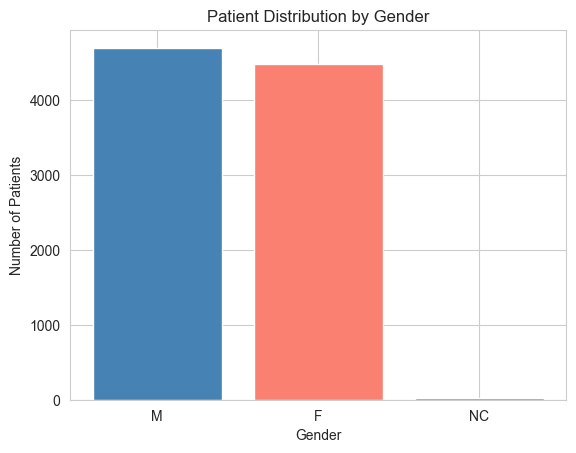

In [11]:
colors= ['steelblue', 'salmon', 'gray']
plt.figure()
plt.bar(gender_dist['Count'], gender_dist['count'],color=colors)
plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()

### Insights:-
ER visits are almost evenly split between male (51%) and female(49%) patients, with a small number of non-disclosed cases.

In [12]:
#Patient Population by Race
race_dist = category_distribution(
    df, 'Patient Race', 'Race')

race_dist

,Count,count
0,White,2571
1,African American,1951
2,Two or More Races,1557
3,Asian,1060
4,Declined to Identify,1030
5,Pacific Islander,549
6,Native American/Alaska Native,498


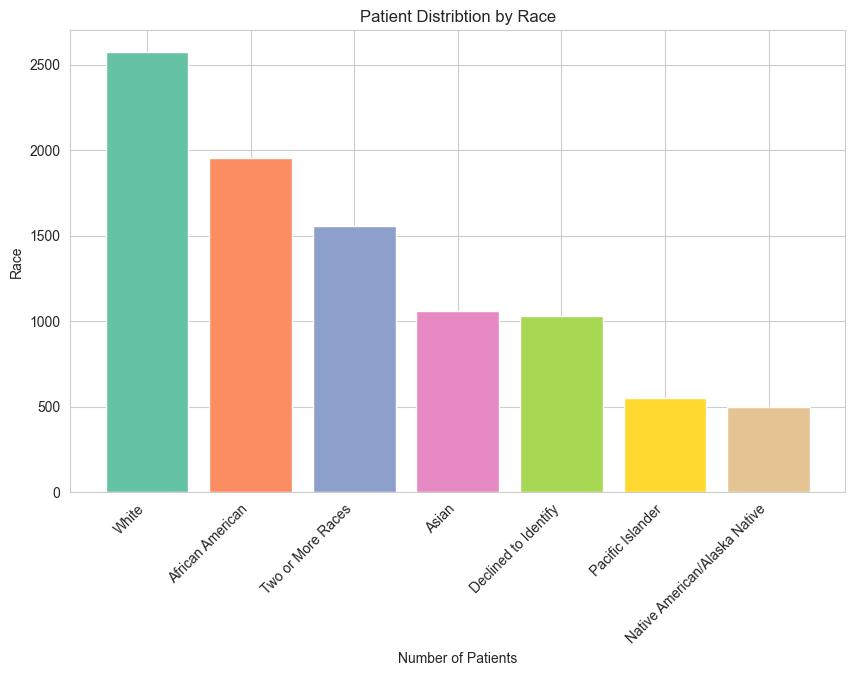

In [13]:
plt.figure(figsize=(10,6))
plt.bar(race_dist['Count'], race_dist['count'],color=plt.cm.Set2.colors)
plt.title('Patient Distribtion by Race')
plt.xlabel('Number of Patients')
plt.ylabel('Race')
plt.xticks(rotation=45,ha= 'right')
plt.show()

### Insights:-

- The ER patient population is predominantly White and African American, with meaningful representation across multiple racial groups.
- Smaller proportions of Pacific Islander and Native American/Alaska Native patients were observed.
- These distributions likely reflect the surrounding community demographics and highlight the diversity of the patient base served by the ER.

In [14]:
#Patient Age Distribution
age_summary= df['Patient Age'].describe()
age_summary

count    9216.000000
mean       39.855143
std        22.755125
min         1.000000
25%        20.000000
50%        39.000000
75%        60.000000
max        79.000000
Name: Patient Age, dtype: float64

In [15]:
# Age Group Segmentation

age_bins = [0,12,18,35,50,65,110]

age_labels= ['Child', 'Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior']

df['Age Group']= pd.cut(df['Patient Age'], bins= age_bins, labels= age_labels)

age_group_dist= category_distribution(
    df, 'Age Group', 'Age Group')

age_group_dist.columns= ['Age Group', 'Patient Count']
age_group_dist

,Age Group,Patient Count
0,Young Adult,1985
1,Adult,1776
2,Middle Age,1728
3,Senior,1617
4,Child,1413
5,Teen,697


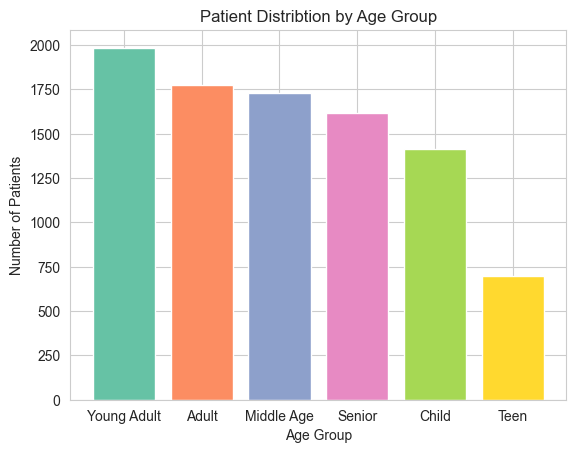

In [16]:
plt.figure()
plt.bar(age_group_dist['Age Group'], age_group_dist['Patient Count'],color=plt.cm.Set2.colors)
plt.title('Patient Distribtion by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.show()

### Insights:- 
- The ER patient population is predominantly composed of young adults and middle-aged individuals, with seniors also representing a substantial share.
- Pediatric and teenage cases form a smaller proportion of total visits.
- This distribution suggests that the ER primarily serves a working-age demographic, which may influence peak demand patterns and operational planning.

### 1.2 How does ER traffic evolve over time — daily, weekly, monthly, seasonally?

ER traffic = number of ER visits over time.

In [17]:
# change the date pattern
df['Patient Admission Date']= pd.to_datetime(df['Patient Admission Date'], format='%d-%m-%Y %H:%M')
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group
960,674-28-0052,2024-05-15 21:27:00,U,Mackriell,F,26,Two or More Races,General Practice,True,0.0,30,0,Young Adult


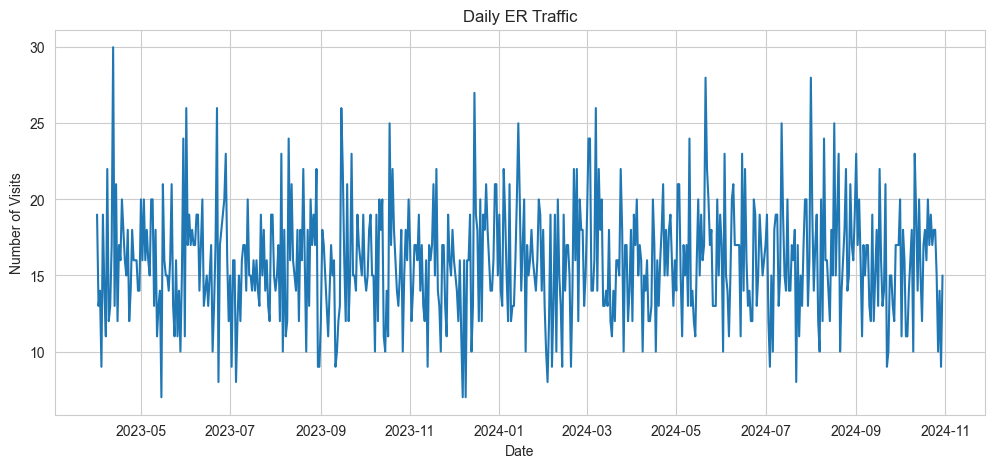

In [18]:
#How many patients visit the ER each day?
daily_traffic=(df.groupby(df['Patient Admission Date'].dt.date).size())
plt.figure(figsize=(12,5))
plt.plot(daily_traffic)
plt.title('Daily ER Traffic')
plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.show()

### Insight:- 
- Daily ER traffic exhibits significant day-to-day variability, with patient visits fluctuating between approximately 8 and 30 per day.
- Despite this volatility, there is no clear long-term upward or downward trend, suggesting relatively stable demand over the observed period

In [19]:
# Which days of the week are busiest?

df['Day of Week']= df ['Patient Admission Date'].dt.day_name()
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week
3564,611-23-0736,2024-07-20 20:09:00,S,McLugaish,M,39,Asian,NaN,False,NaN,33,0,Adult,Saturday


In [20]:
# to generate dataset for checking buiest weeks and months
weekly_traffic= time_distribution(df,'Patient Admission Date','day')
weekly_traffic

,Day,Count
0,Monday,1314
1,Tuesday,1305
2,Wednesday,1260
3,Thursday,1332
4,Friday,1310
5,Saturday,1377
6,Sunday,1318


In [21]:
monthly_traffic= time_distribution (df,'Patient Admission Date','month')
monthly_traffic

,Month,Count
0,January,513
1,February,431
2,March,506
3,April,948
4,May,999
5,June,991
6,July,952
7,August,1024
8,September,935
9,October,964


In [22]:
# Store datasets and metadata
datasets = [(weekly_traffic, 'Day', 'Seasonal ER Traffic (By Week)'),(monthly_traffic, 'Month', 'Seasonal ER Traffic (By Month)')]

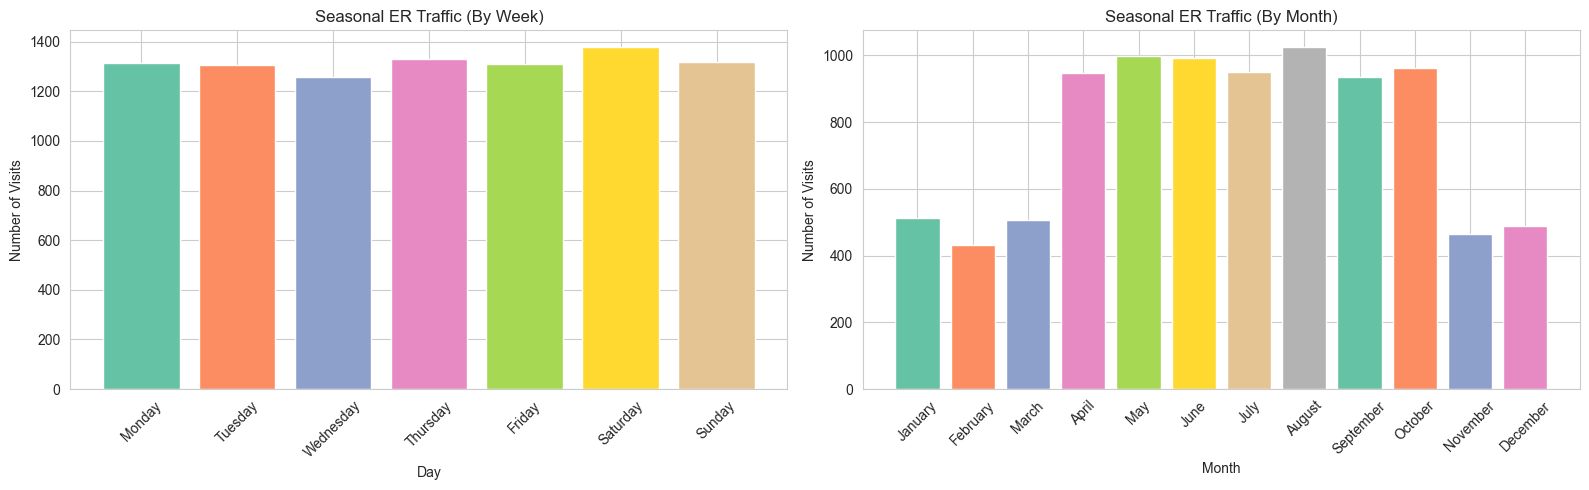

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

for ax, (data, x_col, title) in zip(axes, datasets):
    ax.bar(data[x_col], data['Count'], color=plt.cm.Set2.colors)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel('Number of Visits')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insights:-
#### Weekly ER traffic( By Day)
- ER demand is relatively consistent throughout the week, with a slight increase on Saturdays, suggesting minor weekend-related surges but no strong weekday bottleneck pattern.

#### Monthly ER traffic
- ER visits increase significantly during late spring and summer months, peaking in August, while winter months show comparatively lower traffic.

### 1.3 What are the average, median, and extreme wait times?

In [24]:
# extract only patient waittime variables and copy the dataset and check the statistical insights
df_wait= df[['Patient Waittime']].copy()
df_wait.describe()

,Patient Waittime
count,9216.000000
mean,35.259874
std,14.735323
min,10.000000
25%,23.000000
50%,35.000000
75%,48.000000
max,60.000000


### Insights:-
- Patients typically wait around 35 minutes.
- The shortest recorded wait is 10 minutes.
- The longest wait time is 60 minutes.

### 1.4 What share of patients get admitted versus discharged?

"Patient Admission Flag"
- True → Patient admitted
- False → Patient discharged

In [25]:
# to count admission and its percentage
admission_counts, admission_percent= get_distribution(df, 'Patient Admission Flag')
print(admission_counts)
print(admission_percent)

Patient Admission Flag
True     4612
False    4604
Name: count, dtype: int64
Patient Admission Flag
True     50.043403
False    49.956597
Name: proportion, dtype: float64


### 1.5 How are patients distributed across departments, triage levels, or referral types?

In [26]:
# Distribution across departments
df['Department Referral Filled'] = df['Department Referral'].fillna('No Referral')
dept_counts, dept_percent= get_distribution(df, 'Department Referral Filled')

In [27]:
print(dept_counts)
print(dept_percent)

Department Referral Filled
No Referral         5400
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: count, dtype: int64
Department Referral Filled
No Referral         58.593750
General Practice    19.965278
Orthopedics         10.796441
Physiotherapy        2.994792
Cardiology           2.690972
Neurology            2.094184
Gastroenterology     1.931424
Renal                0.933160
Name: proportion, dtype: float64


#### Distribution across triage levels
Explanation:- Triage is a healthcare process used to prioritize patients based on how urgent their condition is
- More urgent patients are seen first
- Less urgent patients can safely wait


CM = Case Management Triage categories

- 0 → Low urgency / routine care
- 1 → Moderate urgency
- 2+ → High urgency / immediate attention

In [28]:
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled
4893,593-14-3392,2024-04-08 04:16:00,I,Summerlad,M,66,White,NaN,False,1.0,28,0,Senior,Monday,No Referral


In [29]:
# calculate percentage and counts to find out the urgency category count according the triage analysis
triage_counts, triage_percent= get_distribution(df, 'Patients CM')
print(triage_counts)
print(triage_percent)

Patients CM
0    8736
1     480
Name: count, dtype: int64
Patients CM
0    94.791667
1     5.208333
Name: proportion, dtype: float64


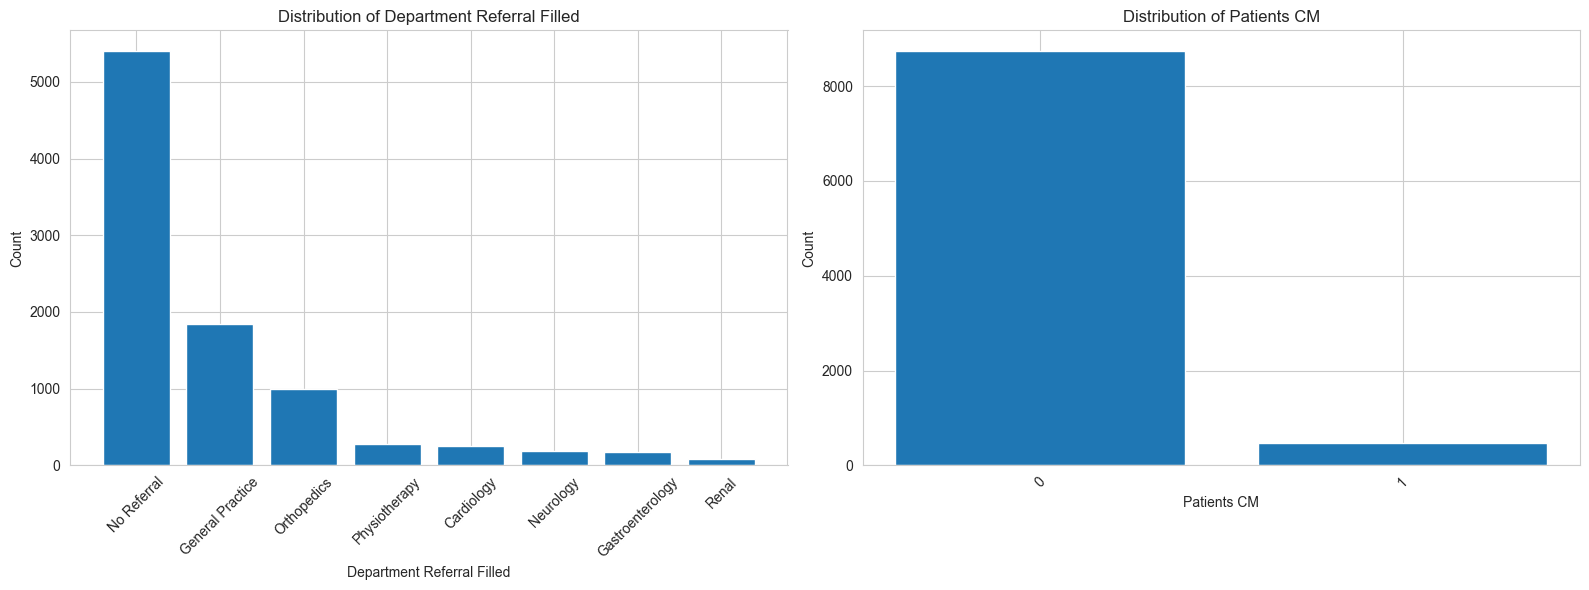

In [30]:
# create subplot to show wmost patient are visit which department and their category of cases (critical / non critical)
cols_to_plot = ["Department Referral Filled", "Patients CM"]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(16, 6))

for i, col in enumerate(cols_to_plot):
# Use the reusable function here  
    counts, percent = get_distribution(df, col)
    
    # Plot the counts
    axes[i].bar(counts.index.astype(str), counts.values)
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insights:- 
##### Distribution of Department Referral Filled:- 
A large proportion of patients have no recorded department referral, suggesting that many cases were handled without a formal departmental referral or that referral information was not captured in the dataset.

##### Distribution of Patient CM:- 
The majority of patients fall under the lowest case management or triage category, indicating that most visits are non-critical.

# 2. Patient Demographics Analysis

## 2.1 Do men and women experience different wait times?

In [31]:
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled
1133,343-72-2599,2023-06-21 03:01:00,E,Jonke,F,68,African American,NaN,False,NaN,47,0,Senior,Wednesday,No Referral


- M= Men
- F- Women
- NC = Not Classified / Not Captured

In [32]:
# check according to gender what are their waittime
gender_waittime= grouped_summary(df,'Patient Gender','Patient Waittime')
gender_waittime

,count,mean,std,min,25%,50%,75%,max
Patient Gender,,,,,,,,
F,4487.0,35.105416,14.676244,10.0,23.0,35.0,48.0,60.0
M,4705.0,35.397450,14.803092,10.0,23.0,36.0,48.0,60.0
NC,24.0,37.166667,12.376930,10.0,31.0,37.5,44.5,59.0


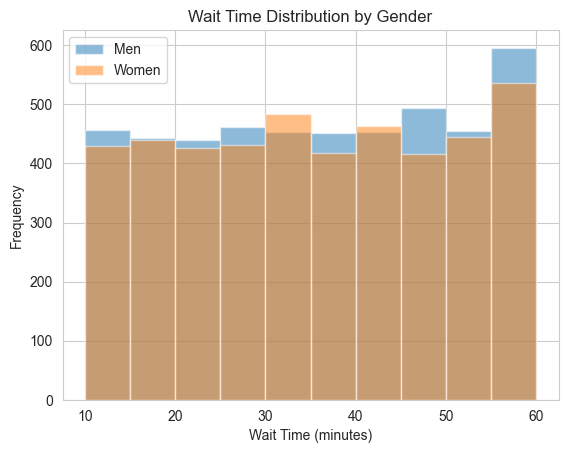

In [33]:
#create plot
plt.hist(df[df["Patient Gender"]=="M"]["Patient Waittime"], alpha=0.5, label="Men")
plt.hist(df[df["Patient Gender"]=="F"]["Patient Waittime"], alpha=0.5, label="Women")
plt.xlabel("Wait Time (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Wait Time Distribution by Gender")
plt.show()

#### Insights:- 
- Men and women have nearly identical wait-time distributions, with heavy overlap across all time ranges, indicating no meaningful gender-based difference.

- Longer waits (around 50–60 minutes) occur frequently for both groups, suggesting wait time is driven by operational factors rather than gender.

### 2.1 How do wait times differ for children, adults, and elderly patients?

In [34]:
#check according the age of waittime
waittime_age_group= grouped_summary(df,'Age Group','Patient Waittime')

In [35]:
waittime_age_group

,count,mean,std,min,25%,50%,75%,max
Age Group,,,,,,,,
Child,1413.0,35.302902,14.465803,10.0,23.0,35.0,48.0,60.0
Teen,697.0,35.350072,15.264365,10.0,22.0,36.0,49.0,60.0
Young Adult,1985.0,35.499748,14.705377,10.0,23.0,36.0,48.0,60.0
Adult,1776.0,35.351914,14.720591,10.0,22.0,35.0,49.0,60.0
Middle Age,1728.0,34.864583,14.956031,10.0,22.0,35.0,47.0,60.0
Senior,1617.0,35.210266,14.565160,10.0,23.0,35.0,48.0,60.0


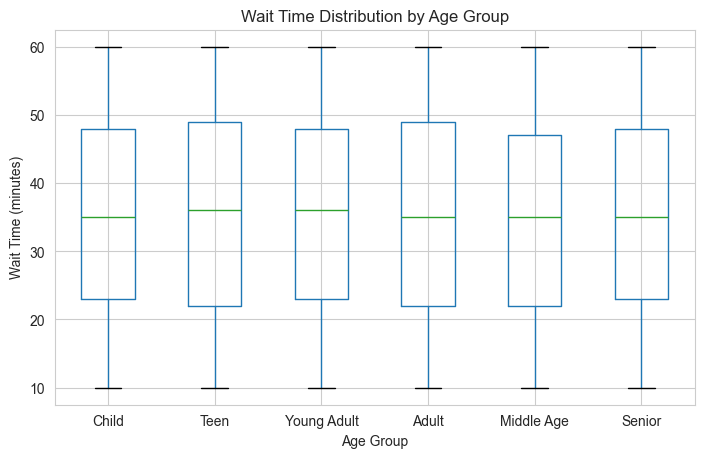

In [36]:
df.boxplot(column="Patient Waittime", by="Age Group", figsize=(8,5))
plt.title("Wait Time Distribution by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Wait Time (minutes)")
plt.show()

#### Insights:-
- All age groups show very similar wait-time distributions.

- The median wait time is around 35 minutes for every age group.

- The spread (IQR) and the minimum/maximum wait times are nearly identical.

- No group (children, adults, seniors) experiences meaningfully longer or shorter waits.

- This suggests the clinic/hospital maintains a consistent and age-neutral triage process.

### 2.3 Are certain racial or ethnic groups visiting the ER more frequently?

In [37]:
#check how many patient visited ER devided according their races
patient_race_ER_visit= df['Patient Race'].value_counts()
patient_race_ER_visit

Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64

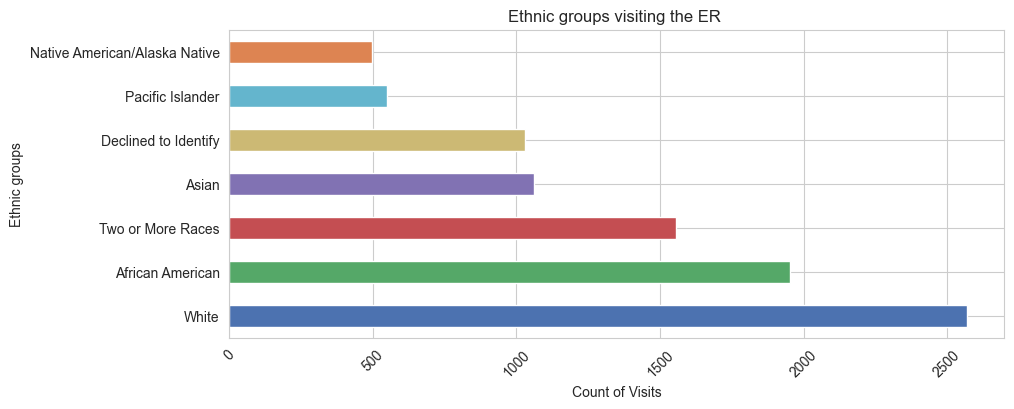

In [38]:
patient_race_ER_visit.plot(kind="barh", figsize=(10,4),color=["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#64B5CD", "#DD8452"])

plt.title("Ethnic groups visiting the ER ")
plt.xlabel("Count of Visits")
plt.ylabel("Ethnic groups")
plt.xticks(rotation=45)
plt.show()

### Insights:- 
- ER patient population is predominantly composed of White and African American individuals.
- While some groups account for smaller proportions of total visits, the overall distribution reflects a diverse patient base.

### 2.4 Which demographic groups have the highest admission rates?
In here we devide 2 demographic groups one by Age and other by Ethnic group

In [39]:
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled
3694,469-90-5298,2023-04-07 06:40:00,R,Huggett,M,39,Declined to Identify,General Practice,False,NaN,27,0,Adult,Friday,General Practice


In [40]:
# check according the admission which age group mostly admitted in ER
age_group_highest_admission= (df[df['Patient Admission Flag']].groupby('Age Group').size())
age_group_highest_admission

C:\Users\Subrata\AppData\Local\Temp\ipykernel_16956\3868897016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_highest_admission= (df[df['Patient Admission Flag']].groupby('Age Group').size())


Age Group
Child          720
Teen           362
Young Adult    987
Adult          878
Middle Age     861
Senior         804
dtype: int64

In [41]:
# check according the patient's race which category of races admitted most
patient_race_highest_admission= (df[df['Patient Admission Flag']].groupby('Patient Race').size())
patient_race_highest_admission

Patient Race
African American                  995
Asian                             541
Declined to Identify              508
Native American/Alaska Native     251
Pacific Islander                  265
Two or More Races                 763
White                            1289
dtype: int64

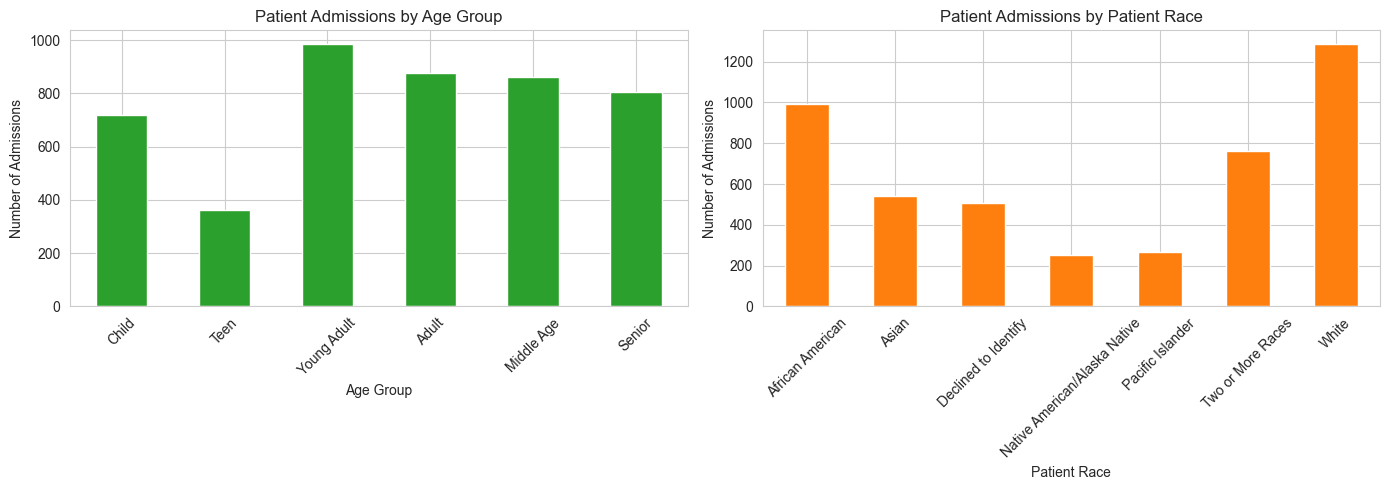

In [42]:
plots = [
    (age_group_highest_admission, 'Age Group', 'Patient Admissions by Age Group', 'tab:green'),
    (patient_race_highest_admission, 'Patient Race', 'Patient Admissions by Patient Race', 'tab:orange')
]

fig, axes = plt.subplots(1, len(plots), figsize=(14, 5))

for i, (data, xlabel, title, color) in enumerate(plots):
    data.plot(kind='bar', ax=axes[i], color=color)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel('Number of Admissions')
    axes[i].set_title(title)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insights:- 
- Age Group: Admissions peak among Young Adults and remain high through adulthood and senior years, while Teens show the lowest healthcare utilization.

- Patient Race: Admissions are highest among White and African American patients, with substantially lower counts in smaller racial groups, reflecting underlying demographic and access differences rather than medical need alone.

### 2.5 Are specific demographics more likely to be routed to certain departments?

In [43]:
# filter patients those admitted in ER
admitted_df=df[df['Patient Admission Flag']== True]

In [44]:
# check which departemnt patients admitted according to their age group
age_dept= (pd.crosstab(admitted_df['Age Group'],admitted_df['Department Referral'], normalize= 'index')*100)
age_dept

Department Referral,Cardiology,Gastroenterology,General Practice,Neurology,Orthopedics,Physiotherapy,Renal
Age Group,,,,,,,
Child,6.164384,4.109589,44.520548,6.164384,29.452055,6.506849,3.082192
Teen,4.605263,5.263158,44.078947,5.263158,26.973684,11.184211,2.631579
Young Adult,6.947891,2.977667,46.153846,4.962779,28.039702,8.436725,2.481390
Adult,5.413105,5.413105,50.997151,5.413105,23.076923,6.552707,3.133903
Middle Age,7.988981,4.683196,47.107438,5.509642,27.823691,4.958678,1.928375
Senior,6.666667,6.666667,48.888889,3.809524,24.126984,8.253968,1.587302


In [45]:
# check according the race which department they admitted
race_dept= (pd.crosstab(admitted_df['Patient Race'],admitted_df['Department Referral'],normalize= 'index')*100)
race_dept

Department Referral,Cardiology,Gastroenterology,General Practice,Neurology,Orthopedics,Physiotherapy,Renal
Patient Race,,,,,,,
African American,6.082725,5.839416,45.985401,5.839416,26.277372,7.299270,2.676399
Asian,7.207207,4.054054,50.900901,3.153153,24.324324,6.756757,3.603604
Declined to Identify,5.445545,5.940594,45.049505,7.425743,26.732673,6.930693,2.475248
Native American/Alaska Native,9.259259,3.703704,43.518519,9.259259,27.777778,4.629630,1.851852
Pacific Islander,8.403361,6.722689,45.378151,7.563025,21.008403,8.403361,2.521008
Two or More Races,7.491857,4.560261,51.465798,3.583062,26.384365,5.211726,1.302932
White,5.325444,3.550296,46.351085,4.142012,28.796844,9.270217,2.564103


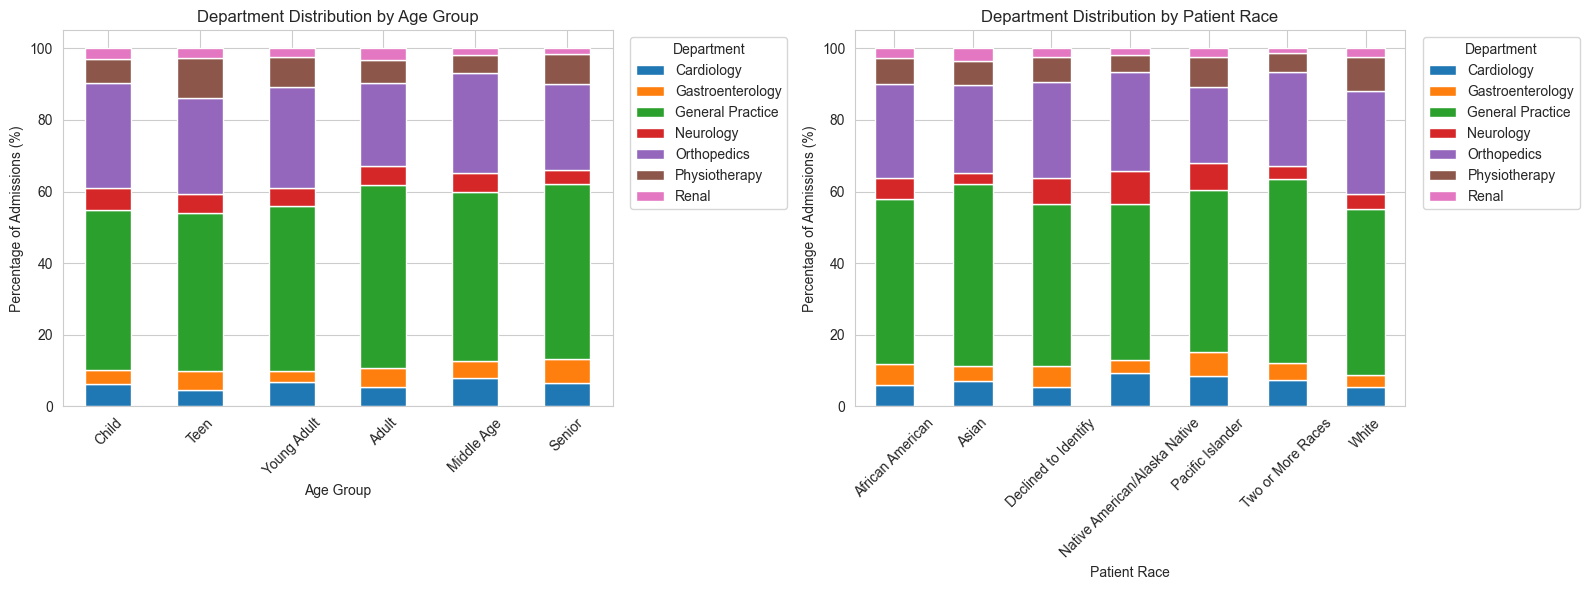

In [46]:

plots = [
    (age_dept, 'Age Group', 'Department Distribution by Age Group'),
    (race_dept, 'Patient Race', 'Department Distribution by Patient Race')
]


fig, axes = plt.subplots(1, len(plots), figsize=(16, 6))

for i, (data, xlabel, title) in enumerate(plots):
    data.plot(
        kind='bar',
        stacked=True,
        ax=axes[i]
    )
    
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel('Percentage of Admissions (%)')
    axes[i].set_title(title)
    axes[i].legend(
        title='Department',
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### Insights:-
- Department Distribution by Age Group
  
General Practice dominates across all age groups, while Orthopedics increases notably in adults and seniors, reflecting age-related mobility and joint issues.
- Department Distribution by Patient Race
  
Although majority of people visits in general practice department regardless of race, the differences in how patients are distributed across specialties (like orthopedics or neurology) show that health needs and treatment paths vary, not that everyone follows the same system of care.

# 3. ER Operations & Efficiency

### 3.1 Which departments consistently have the longest or shortest wait times?

In [47]:
# calculate according the departemt which departmet waittime is the longest
dept_wait_summary = (df.groupby('Department Referral', observed = False)['Patient Waittime']
                      .describe().sort_values('mean', ascending = False))
dept_wait_summary

,count,mean,std,min,25%,50%,75%,max
Department Referral,,,,,,,,
Neurology,193.0,36.803109,14.657997,10.0,24.00,38.0,49.0,60.0
Physiotherapy,276.0,36.565217,14.624739,10.0,24.00,38.5,49.0,60.0
Gastroenterology,178.0,35.831461,14.661326,10.0,23.25,36.0,48.0,60.0
Cardiology,248.0,35.354839,15.468758,10.0,21.00,35.0,50.0,60.0
Orthopedics,995.0,34.982915,14.820954,10.0,22.00,34.0,48.0,60.0
General Practice,1840.0,34.912500,14.982479,10.0,22.00,35.0,48.0,60.0
Renal,86.0,34.697674,14.417367,10.0,24.25,35.0,46.5,60.0


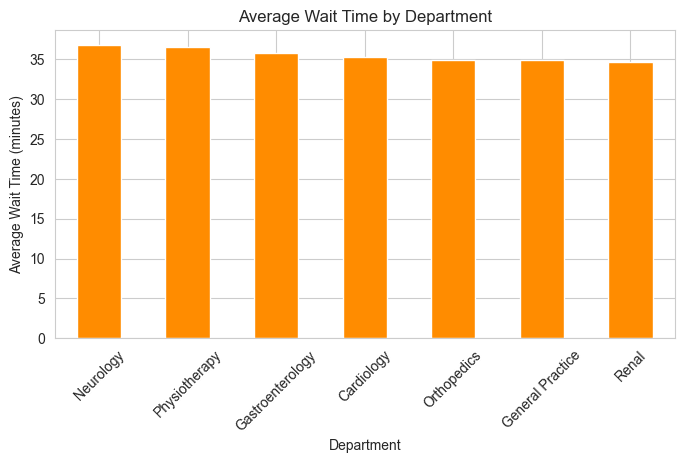

In [48]:
dept_wait_summary['mean'].plot(kind='bar', figsize=(8,4), color='darkorange')
plt.title('Average Wait Time by Department')
plt.xlabel('Department')
plt.ylabel('Average Wait Time (minutes)')
plt.xticks(rotation=45)
plt.show()

#### Insights:-
- Neurology/Physiotherapy: longest waits (~36–37 min), suggesting high complexity/demand.
- Renal/General Practice/Orthopedics: shortest (~34–35 min), faster throughput.
- Waits consistent across departments (±2–3 min); shared min/max (10–60 min) limits.

### 3.2 Are admission rates concentrated in certain departments?

In [49]:
# check which departement has most ER patients and how many has admitted
dept_admission = (df.groupby('Department Referral', observed= False) ['Patient Admission Flag']
                  .agg(total_visits= 'count', admitted= 'sum', admission_rate= 'mean'))
dept_admission

,total_visits,admitted,admission_rate
Department Referral,,,
Cardiology,248,122,0.491935
Gastroenterology,178,89,0.500000
General Practice,1840,887,0.482065
Neurology,193,97,0.502591
Orthopedics,995,498,0.500503
Physiotherapy,276,137,0.496377
Renal,86,46,0.534884


In [50]:
# convert rate into percentage
dept_admission['admission rate']= dept_admission['admission_rate']*100
dept_admission

,total_visits,admitted,admission_rate,admission rate
Department Referral,,,,
Cardiology,248,122,0.491935,49.193548
Gastroenterology,178,89,0.500000,50.000000
General Practice,1840,887,0.482065,48.206522
Neurology,193,97,0.502591,50.259067
Orthopedics,995,498,0.500503,50.050251
Physiotherapy,276,137,0.496377,49.637681
Renal,86,46,0.534884,53.488372


In [51]:
#sort by admission rate
dept_admission = dept_admission.sort_values('admission_rate', ascending= False)
dept_admission

,total_visits,admitted,admission_rate,admission rate
Department Referral,,,,
Renal,86,46,0.534884,53.488372
Neurology,193,97,0.502591,50.259067
Orthopedics,995,498,0.500503,50.050251
Gastroenterology,178,89,0.500000,50.000000
Physiotherapy,276,137,0.496377,49.637681
Cardiology,248,122,0.491935,49.193548
General Practice,1840,887,0.482065,48.206522


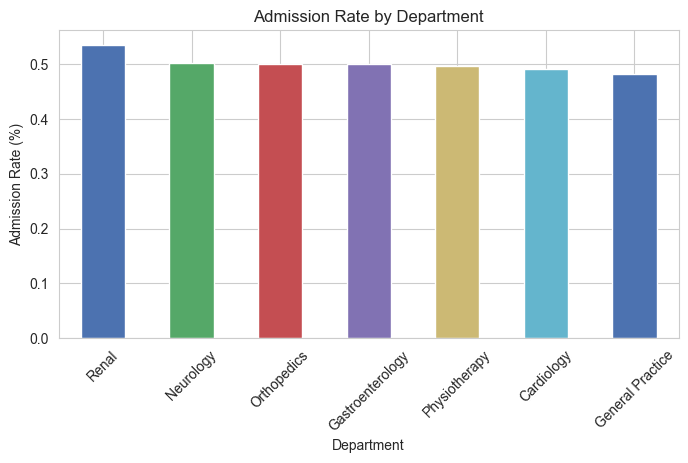

In [52]:
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#64B5CD"]

dept_admission["admission_rate"].plot(
    kind="bar",
    figsize=(8,4),
    color=colors
)

plt.title("Admission Rate by Department")
plt.xlabel("Department")
plt.ylabel("Admission Rate (%)")
plt.xticks(rotation=45)
plt.show()


#### Insights :-
- Renal: highest admission rate (~53%), indicating more inpatient needs.
- Neurology/Orthopedics: high (~50%), suggesting case severity.
- General Practice: lowest (~48%), more outpatient cases.
- Rates similar (48–53%) across departments; driven by clinical need.

### 3.3 When do bottlenecks occur — specific hours, days, or seasons?

In [53]:
# create one column only for to calculate the hour
df['hour']= df['Patient Admission Date'].dt.hour
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled,hour
437,241-06-7024,2023-10-01 15:44:00,E,Cutress,F,19,African American,Physiotherapy,True,1.0,60,0,Young Adult,Sunday,Physiotherapy,15


In [54]:
# check average waittime by clock( 0 means 12 am, 1 means 1am)
hourly_wait = average_by_time_unit(df,'Patient Admission Date','Patient Waittime',unit='hour')
hourly_wait

,Timeunit,Patient Waittime
0,0,34.251232
1,1,34.064516
2,2,35.364362
3,3,37.218182
4,4,34.929688
5,5,36.386768
6,6,35.133333
7,7,35.262651
8,8,35.321244
9,9,36.360825


In [55]:
# create one column to check which day is it
df['day']= df['Patient Admission Date'].dt.day_name()
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled,hour,day
2941,825-01-3965,2023-11-17 19:44:00,Z,Rumke,F,75,White,Orthopedics,False,NaN,17,0,Senior,Friday,Orthopedics,19,Friday


In [56]:
# check which dy has patient average wait time
daily_wait= average_by_time_unit(df,'Patient Admission Date','Patient Waittime',unit='day')
daily_wait

,Timeunit,Patient Waittime
0,Friday,35.075573
1,Monday,35.668189
2,Saturday,35.649964
3,Sunday,35.247344
4,Thursday,34.879129
5,Tuesday,35.093487
6,Wednesday,35.187302


In [57]:
# check which month waittime is the longest
monthly_wait = average_by_time_unit(df,'Patient Admission Date','Patient Waittime',unit='month')
monthly_wait

,Timeunit,Patient Waittime
0,April,34.972574
1,August,35.730469
2,December,34.764826
3,February,36.670534
4,January,36.323587
5,July,34.965336
6,June,35.544904
7,March,35.879447
8,May,35.146146
9,November,35.185345


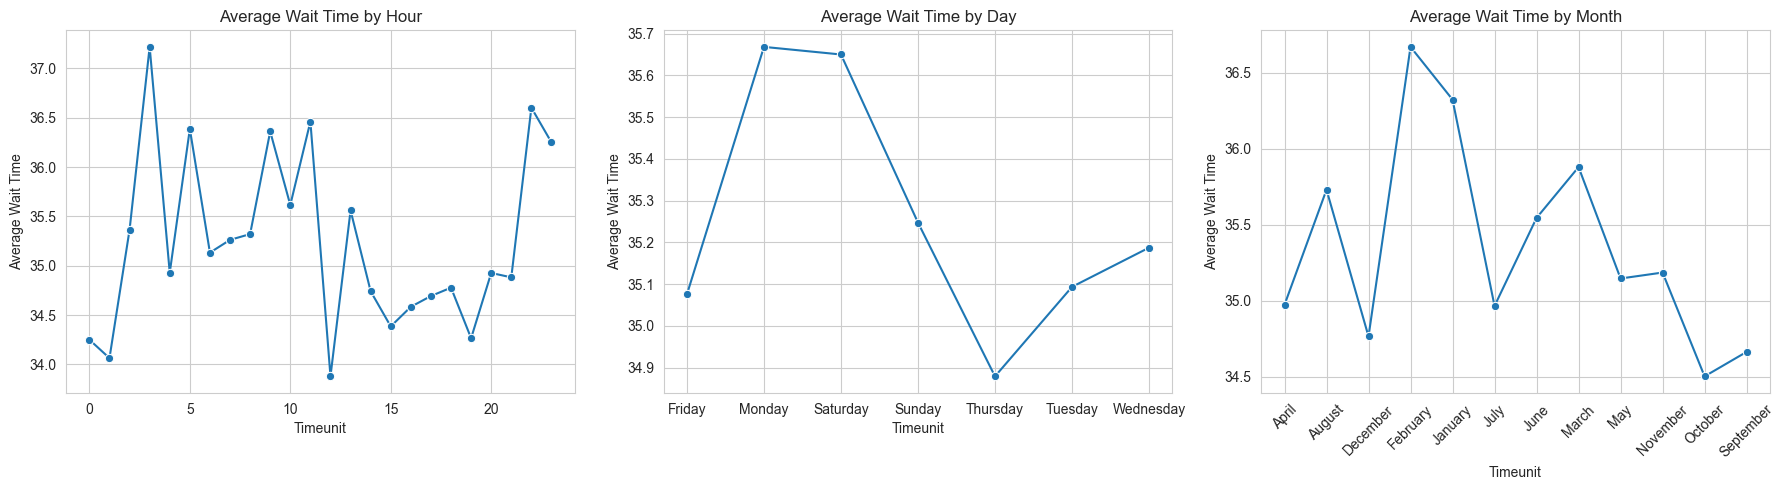

In [58]:

# Store your results in a list
datasets = [
    (hourly_wait, 'Timeunit', 'Patient Waittime', 'Average Wait Time by Hour'),
    (daily_wait, 'Timeunit', 'Patient Waittime', 'Average Wait Time by Day'),
    (monthly_wait, 'Timeunit', 'Patient Waittime', 'Average Wait Time by Month')
]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (data, x_col, y_col, title) in zip(axes, datasets):
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', ax=ax)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Average Wait Time")

    # Rotate labels only for month plot
    if 'Month' in title:
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insights:- 
- Average Wait Time by Hour :- No severe hourly bottleneck exists, though minor overnight inefficiencies may occur.
- Average Wait Time by Day :- The ER maintains operational stability across weekdays with no clear weekly bottleneck pattern.
- Average Wait Time by Month:- Seasonal traffic increases do not substantially inflate average wait times, suggesting adequate capacity management.

### 3.4 Does a longer wait time increase or decrease the likelihood of admission?

In [59]:
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled,hour,day
2272,719-53-7812,2023-12-29 02:34:00,T,Crocetto,F,79,Two or More Races,NaN,False,NaN,16,0,Senior,Friday,No Referral,2,Friday


In [60]:
#compare average wait time by admission status
wait_time= df.groupby('Patient Admission Flag')['Patient Waittime'].mean()
wait_time

Patient Admission Flag
False    35.552346
True     34.967910
Name: Patient Waittime, dtype: float64

In [61]:
#calculate admission rate by creating a wait time category(devide waiitime into small bins which 15 minutes distribution)
df['wait category']= pd.cut(df['Patient Waittime'], bins= [0,15,30,40,60,120], labels= ['0-15', '15-30', '30-45','45-60','60+'])
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled,hour,day,wait category
5086,774-96-3514,2023-07-14 18:42:00,E,Sarfass,F,53,African American,Cardiology,True,NaN,44,0,Middle Age,Friday,Cardiology,18,Friday,45-60


In [62]:
# check according the wait time what is the rate of admission
admission_rate= (df.groupby('wait category')['Patient Admission Flag'].mean().reset_index())
admission_rate

C:\Users\Subrata\AppData\Local\Temp\ipykernel_16956\348006566.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  admission_rate= (df.groupby('wait category')['Patient Admission Flag'].mean().reset_index())


,wait category,Patient Admission Flag
0,0-15,0.517560
1,15-30,0.507687
2,30-45,0.502242
3,45-60,0.489275
4,60+,NaN


C:\Users\Subrata\AppData\Local\Temp\ipykernel_16956\2301160891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


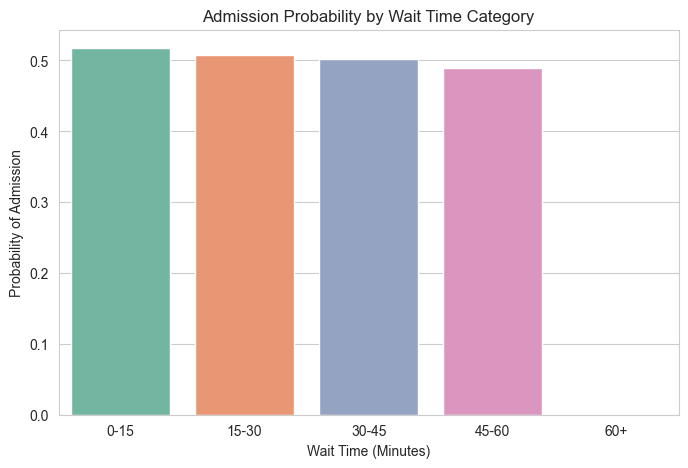

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=admission_rate,x='wait category',y='Patient Admission Flag', palette='Set2')

plt.title('Admission Probability by Wait Time Category')
plt.ylabel('Probability of Admission')
plt.xlabel('Wait Time (Minutes)')
plt.show()

### Insights:- 
- Admission probability remains relatively consistent across wait time categories, with only minor variation observed.
- This suggests that wait duration alone is not a strong predictor of hospital admission.
- The slight decrease in admission likelihood for longer wait times may reflect triage prioritization, where more severe cases are seen and admitted more quickly.

# 4. Correlation & Relationship Analysis

### 4.1 How strongly are wait times correlated with satisfaction scores?

In [64]:
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled,hour,day,wait category
5406,575-57-1946,2023-10-18 03:51:00,A,Pietrzak,F,41,African American,NaN,True,4.0,21,0,Adult,Wednesday,No Referral,3,Wednesday,15-30


In [65]:
#drop missing satisfaction score
corr_df= df[['Patient Waittime','Patient Satisfaction Score']].dropna()
corr_df

,Patient Waittime,Patient Satisfaction Score
0,39,10.0
2,55,9.0
3,31,8.0
8,42,1.0
19,40,2.0
...,...,...
9204,34,7.0
9205,58,8.0
9206,56,10.0
9209,44,4.0


In [66]:
#corelation calculation according waittime and patient satisfaction score
corr= corr_df['Patient Waittime'].corr(corr_df['Patient Satisfaction Score'])
corr

np.float64(-0.02118296963857251)

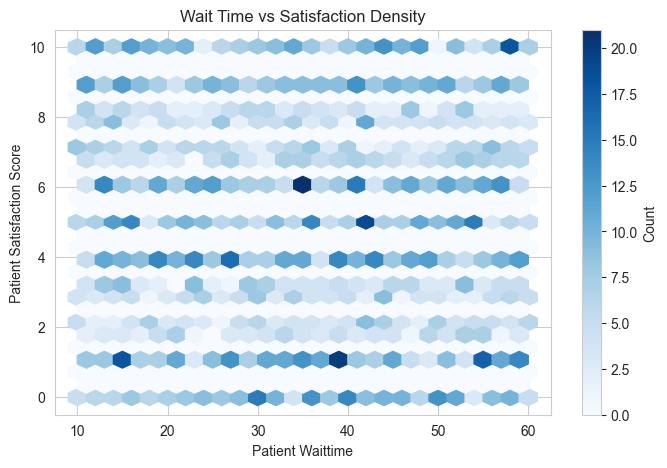

In [67]:
plt.figure(figsize=(8,5))

plt.hexbin(
    corr_df['Patient Waittime'],
    corr_df['Patient Satisfaction Score'],
    gridsize=25,
    cmap='Blues'
)

plt.colorbar(label='Count')
plt.xlabel('Patient Waittime')
plt.ylabel('Patient Satisfaction Score')
plt.title('Wait Time vs Satisfaction Density')
plt.show()

### Insights:- 
- The density analysis shows no strong relationship between patient wait time and satisfaction score.
- Although minor variation exists, high satisfaction ratings are observed across all wait durations.
- This suggests that factors beyond wait time, such as quality of care or communication, may play a more significant role in shaping patient experience.

### 4.2 Are admission decisions influenced by age, wait time, or both?

In [68]:
# drop where in where there is null value in these 3 columns
influence_corr= df[['Patient Waittime','Patient Admission Flag', 'Patient Age']].dropna()
influence_corr

,Patient Waittime,Patient Admission Flag,Patient Age
0,39,False,69
1,27,True,4
2,55,True,56
3,31,True,24
4,10,False,5
...,...,...,...
9211,43,True,42
9212,49,True,19
9213,36,True,14
9214,38,True,73


In [69]:
# convert patient admission flag string to numeric (if its True the it will be 1 otherwise 0) 
influence_corr['Patient Admission Flag']= influence_corr['Patient Admission Flag'].astype(int)
influence_corr

,Patient Waittime,Patient Admission Flag,Patient Age
0,39,0,69
1,27,1,4
2,55,1,56
3,31,1,24
4,10,0,5
...,...,...,...
9211,43,1,42
9212,49,1,19
9213,36,1,14
9214,38,1,73


In [70]:
## check is there any coorelation between 3 variables
correlation_matrix =influence_corr[['Patient Waittime','Patient Admission Flag', 'Patient Age']].corr()
correlation_matrix

,Patient Waittime,Patient Admission Flag,Patient Age
Patient Waittime,1.000000,-0.019832,-0.005636
Patient Admission Flag,-0.019832,1.000000,-0.009613
Patient Age,-0.005636,-0.009613,1.000000


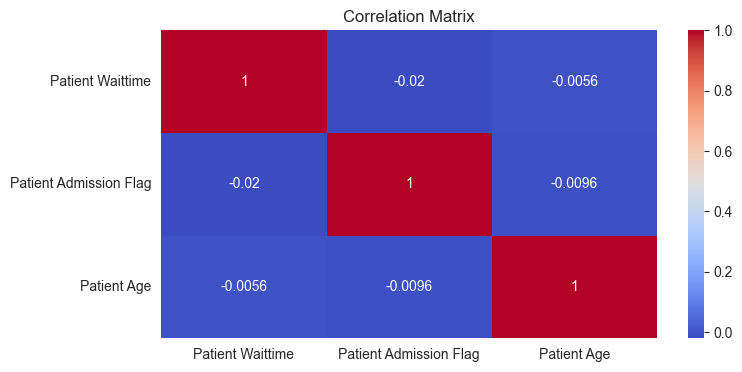

In [71]:
plt.figure(figsize=(8,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Insights:- 
- Correlation analysis reveals negligible relationships between patient wait time, admission status, and age.
- All correlation coefficients were near zero, indicating that these variables operate largely independently within the dataset.
- This suggests that admission decisions and wait durations are not strongly influenced by patient age.

### 4.3 Which variables are the strongest predictors of low satisfaction?

#### 
- 1 = Low satisfaction

- 0 = Not low

In [72]:
# make a low satisfaction column and mark it 3 is threshold for lower satisfaction
df['Low Satisfaction']= (df['Patient Satisfaction Score']<=3).astype(int)
df.sample()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM,Age Group,Day of Week,Department Referral Filled,hour,day,wait category,Low Satisfaction
7354,741-16-1016,2024-03-05 11:34:00,S,Fendley,M,47,African American,NaN,True,NaN,33,0,Adult,Tuesday,No Referral,11,Tuesday,30-45,0


In [73]:
# make a dataset with 4 variables and check coorelation with low satisfaction
prediction_variable= ['Patient Waittime','Patient Admission Flag', 'Patient Age', 'Department Referral']
prediction_variable

['Patient Waittime',
 'Patient Admission Flag',
 'Patient Age',
 'Department Referral']

In [74]:
# all column compile in X dataset and y create only for satisfaction score
x= df[prediction_variable]
y= df['Low Satisfaction']

In [75]:
# in departemnt reffral all NaN value convert to Unknown
x['Department Referral']= x['Department Referral'].fillna('Unknown')
x

C:\Users\Subrata\AppData\Local\Temp\ipykernel_16956\4178715189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Department Referral']= x['Department Referral'].fillna('Unknown')


,Patient Waittime,Patient Admission Flag,Patient Age,Department Referral
0,39,False,69,Unknown
1,27,True,4,Unknown
2,55,True,56,General Practice
3,31,True,24,General Practice
4,10,False,5,Orthopedics
...,...,...,...,...
9211,43,True,42,General Practice
9212,49,True,19,Unknown
9213,36,True,14,Unknown
9214,38,True,73,General Practice


Each category becomes a separate column with:

1 → belongs to that category

0 → does not belong

In [76]:
x = pd.get_dummies(x, columns=['Department Referral'], drop_first=True)

In [77]:
print(x.columns)

Index(['Patient Waittime', 'Patient Admission Flag', 'Patient Age',
       'Department Referral_Gastroenterology',
       'Department Referral_General Practice', 'Department Referral_Neurology',
       'Department Referral_Orthopedics', 'Department Referral_Physiotherapy',
       'Department Referral_Renal', 'Department Referral_Unknown'],
      dtype='object')


In [78]:
# check correlation between these 3 variables with low satisfaction score
full_data = pd.concat([x, y], axis=1)
correlation_matrix = full_data.corr()
correlation_matrix

,Patient Waittime,Patient Admission Flag,Patient Age,Department Referral_Gastroenterology,Department Referral_General Practice,Department Referral_Neurology,Department Referral_Orthopedics,Department Referral_Physiotherapy,Department Referral_Renal,Department Referral_Unknown,Low Satisfaction
Patient Waittime,1.000000,-0.019832,-0.005636,0.005444,-0.011775,0.015318,-0.006539,0.015566,-0.003703,0.002686,0.012655
Patient Admission Flag,-0.019832,1.000000,-0.009613,-0.000122,-0.018349,0.000631,0.000048,-0.001426,0.006687,0.014828,-0.011251
Patient Age,-0.005636,-0.009613,1.000000,0.015100,0.017292,-0.011857,-0.018253,-0.001987,-0.015005,0.000651,0.011315
Department Referral_Gastroenterology,0.005444,-0.000122,0.015100,1.000000,-0.070093,-0.020525,-0.048823,-0.024658,-0.013620,-0.166942,-0.011640
Department Referral_General Practice,-0.011775,-0.018349,0.017292,-0.070093,1.000000,-0.073047,-0.173759,-0.087757,-0.048474,-0.594143,-0.004286
Department Referral_Neurology,0.015318,0.000631,-0.011857,-0.020525,-0.073047,1.000000,-0.050881,-0.025697,-0.014194,-0.173979,0.000389
Department Referral_Orthopedics,-0.006539,0.000048,-0.018253,-0.048823,-0.173759,-0.050881,1.000000,-0.061127,-0.033765,-0.413849,0.022181
Department Referral_Physiotherapy,0.015566,-0.001426,-0.001987,-0.024658,-0.087757,-0.025697,-0.061127,1.000000,-0.017053,-0.209015,-0.002044
Department Referral_Renal,-0.003703,0.006687,-0.015005,-0.013620,-0.048474,-0.014194,-0.033765,-0.017053,1.000000,-0.115453,-0.005316
Department Referral_Unknown,0.002686,0.014828,0.000651,-0.166942,-0.594143,-0.173979,-0.413849,-0.209015,-0.115453,1.000000,-0.003966


In [79]:
# check low satisfaction acoording higher to lower index
correlation_matrix['Low Satisfaction'].sort_values(ascending=False)

Low Satisfaction                        1.000000
Department Referral_Orthopedics         0.022181
Patient Waittime                        0.012655
Patient Age                             0.011315
Department Referral_Neurology           0.000389
Department Referral_Physiotherapy      -0.002044
Department Referral_Unknown            -0.003966
Department Referral_General Practice   -0.004286
Department Referral_Renal              -0.005316
Patient Admission Flag                 -0.011251
Department Referral_Gastroenterology   -0.011640
Name: Low Satisfaction, dtype: float64

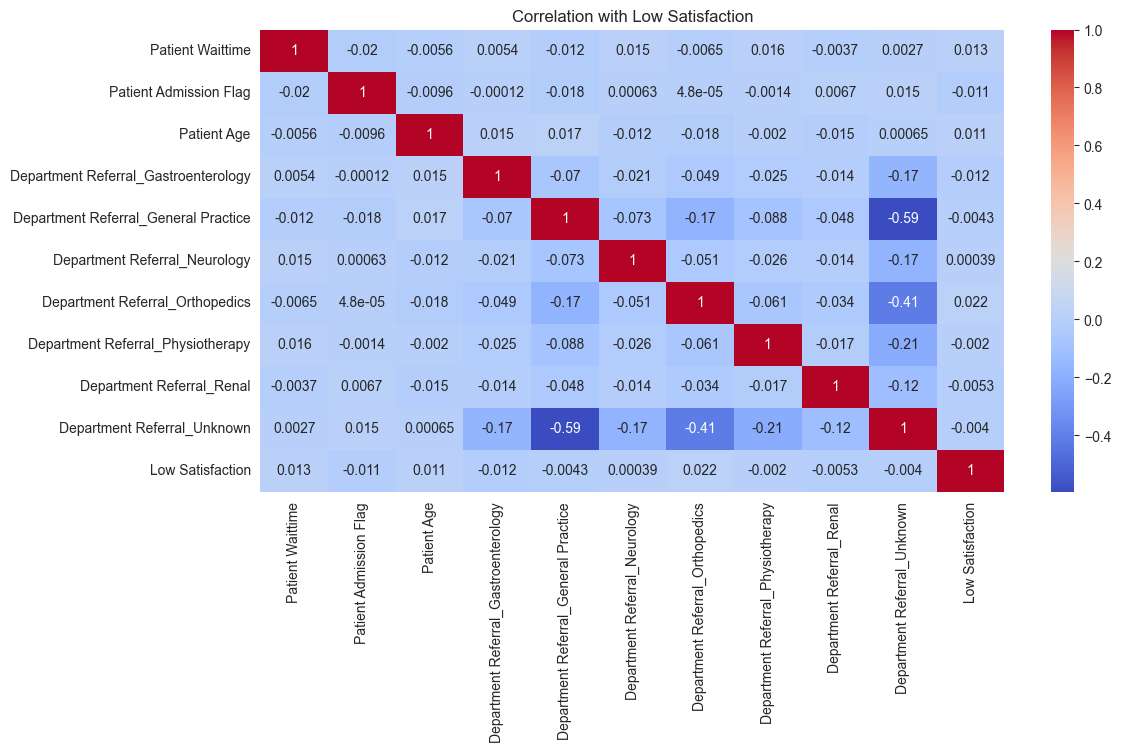

In [82]:
plt.figure(figsize=(12,6))

sns.heatmap(
   correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation with Low Satisfaction')
plt.show()

### Insights:- 
- Multivariable correlation analysis reveals no strong linear predictors of low satisfaction among operational metrics such as wait time, admission status, age, or department referral.
- All correlation coefficients were near zero, suggesting that dissatisfaction may be driven by factors not captured within the dataset, such as patient-provider interaction or care experience quality.

# Key Findings:- 

1️. **Demographic & Department Utilization**
- The ER serves a broad and demographically diverse population.
- The median patient age is approximately 39 years, with visits distributed across all age groups. Gender representation is nearly balanced, with males accounting for approximately 51% and females 49% of total visits.
- Racial distribution reflects diversity, with White and African American patients representing the largest groups, alongside multiple other racial categories.

---
2️. **Case Severity Profile**
- The majority of visits fall within the lowest case-management or triage category, indicating that ER demand is largely driven by lower-acuity cases rather than critical emergencies.

---
3. **Wait Time Stability**
Average wait times remain consistently within the mid-30-minute range across:

- Hours of the day

- Days of the week

- Months of the year

- Genders

- Departments

- Hourly variation was minimal (approximately 34–37 minutes), with slight increases during early morning hours. Weekly and seasonal fluctuations were similarly modest.

---
4. **Admission Patterns**
   
Admission rates are broadly consistent across departments, generally ranging between 48% and 53%. No single department disproportionately drives admissions. Additionally, admission likelihood does not increase with longer wait times.

---
5. **Low Satisfaction Predictors**  
When modeling low satisfaction against wait time, admission status, age, and department (via one-hot encoding), all correlation coefficients with the low-satisfaction flag remain very close to zero:  
**Correlation and density analyses indicate:**

- Minimal relationship between wait time and satisfaction

- Minimal relationship between age and satisfaction

- Minimal relationship between admission status and satisfaction

- Minimal relationship between department referral and satisfaction

- All correlation coefficients with low satisfaction were near zero.

---

6. **Temporal Traffic & Independence of Metrics**  
ER volumes vary over days, weeks, and months, but correlation analysis shows age, wait time, and admission status all have coefficients near zero with one another. 

---